# Module 5: How the Yankees Could Have Prevented This

Volpe had elite plate discipline in the minors. Dominguez has 80-grade raw power. Both are struggling at the MLB level. The front office question isn't just *why* — it's **what systems should have caught this earlier and what would a better development pipeline look like?**

This notebook proposes a Statcast-based framework for prospect readiness that would have flagged both players' specific vulnerabilities before call-up.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="urllib3")

import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from fire_fishman.data.statcast import get_statcast_pitches
from fire_fishman.data.prospects import get_prospect_df

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 7)

pitches_2023 = get_statcast_pitches(2023)
pitches_2024 = get_statcast_pitches(2024)

## 1. The Seasonal Collapse: Volpe's Repeating Pattern

Volpe's overall discipline metrics look fine in aggregate. But month-by-month tells a different story — he starts disciplined and collapses mid-season, **in both 2023 and 2024**. This is a repeating pattern the coaching staff should have caught.

In [2]:
fb_codes = ["FF", "SI", "FC"]
brk_codes = ["SL", "CU", "KC", "SV", "SC"]
off_codes = ["CH", "FS", "FO"]

def monthly_metrics(pitches, pid):
    bp = pitches[pitches["batter"] == pid].copy()
    if len(bp) == 0:
        return pd.DataFrame()
    bp["game_date"] = pd.to_datetime(bp["game_date"])
    bp["month"] = bp["game_date"].dt.month
    bp["is_swing"] = bp["description"].isin([
        "swinging_strike", "swinging_strike_blocked", "foul", "foul_tip",
        "foul_bunt", "hit_into_play", "hit_into_play_score", "hit_into_play_no_out"])
    bp["is_whiff"] = bp["description"].isin(["swinging_strike", "swinging_strike_blocked"])
    bp["is_zone"] = (bp["plate_x"].abs() <= 0.83) & (bp["plate_z"] >= bp["sz_bot"]) & (bp["plate_z"] <= bp["sz_top"])
    
    records = []
    for month in sorted(bp["month"].unique()):
        mp = bp[bp["month"] == month]
        oz = mp[~mp["is_zone"]]
        swings = mp[mp["is_swing"]]
        brk_oz = mp[(mp["pitch_type"].isin(brk_codes)) & (~mp["is_zone"])]
        velo96 = mp[(mp["release_speed"] >= 96) & mp["is_swing"]]
        records.append({
            "month": month, "n": len(mp),
            "chase_rate": oz["is_swing"].mean() if len(oz) > 0 else np.nan,
            "whiff_rate": swings["is_whiff"].mean() if len(swings) > 0 else np.nan,
            "brk_chase": brk_oz["is_swing"].mean() if len(brk_oz) > 0 else np.nan,
            "velo96_whiff": velo96["is_whiff"].mean() if len(velo96) > 0 else np.nan,
        })
    return pd.DataFrame(records)

# Volpe monthly
v23 = monthly_metrics(pitches_2023, 683011)
v24 = monthly_metrics(pitches_2024, 683011)

print("Volpe 2023 Monthly Breaking Ball Chase Rate:")
for _, r in v23[(v23["month"] >= 4) & (v23["n"] > 50)].iterrows():
    bar = "█" * int(r["brk_chase"] * 40)
    print(f"  Month {int(r['month'])}:  {r['brk_chase']:.1%}  {bar}")

print("\nVolpe 2024 Monthly Breaking Ball Chase Rate:")
for _, r in v24[(v24["month"] >= 4) & (v24["n"] > 50)].iterrows():
    bar = "█" * int(r["brk_chase"] * 40)
    print(f"  Month {int(r['month'])}:  {r['brk_chase']:.1%}  {bar}")

Volpe 2023 Monthly Breaking Ball Chase Rate:
  Month 4:  20.6%  ████████
  Month 5:  28.3%  ███████████
  Month 6:  49.1%  ███████████████████
  Month 7:  30.3%  ████████████
  Month 8:  28.6%  ███████████
  Month 9:  35.3%  ██████████████

Volpe 2024 Monthly Breaking Ball Chase Rate:
  Month 4:  29.3%  ███████████
  Month 5:  42.0%  ████████████████
  Month 6:  21.2%  ████████
  Month 7:  34.5%  █████████████
  Month 8:  49.2%  ███████████████████
  Month 9:  35.0%  ██████████████
  Month 10:  35.3%  ██████████████


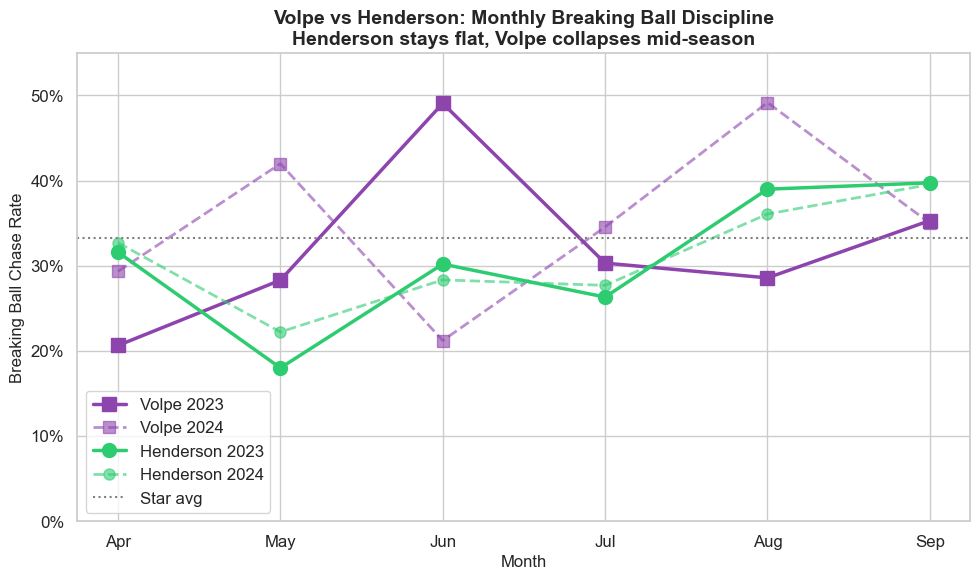

In [3]:
# Compare Volpe vs Henderson month-by-month
h23 = monthly_metrics(pitches_2023, 683002)
h24 = monthly_metrics(pitches_2024, 683002)

months = ["Apr", "May", "Jun", "Jul", "Aug", "Sep"]
v23f = v23[(v23["month"] >= 4) & (v23["month"] <= 9) & (v23["n"] > 50)]
v24f = v24[(v24["month"] >= 4) & (v24["month"] <= 9) & (v24["n"] > 50)]
h23f = h23[(h23["month"] >= 4) & (h23["month"] <= 9) & (h23["n"] > 50)]
h24f = h24[(h24["month"] >= 4) & (h24["month"] <= 9) & (h24["n"] > 50)]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(months[:len(v23f)], v23f["brk_chase"].values, "s-", color="#8e44ad", linewidth=2.5, markersize=10, label="Volpe 2023")
ax.plot(months[:len(v24f)], v24f["brk_chase"].values, "s--", color="#8e44ad", linewidth=2, markersize=8, alpha=0.6, label="Volpe 2024")
ax.plot(months[:len(h23f)], h23f["brk_chase"].values, "o-", color="#2ecc71", linewidth=2.5, markersize=10, label="Henderson 2023")
ax.plot(months[:len(h24f)], h24f["brk_chase"].values, "o--", color="#2ecc71", linewidth=2, markersize=8, alpha=0.6, label="Henderson 2024")
ax.axhline(0.332, color="gray", linestyle=":", linewidth=1.5, label="Star avg")

ax.set_ylabel("Breaking Ball Chase Rate", fontsize=12)
ax.set_xlabel("Month", fontsize=12)
ax.set_title("Volpe vs Henderson: Monthly Breaking Ball Discipline\nHenderson stays flat, Volpe collapses mid-season", fontsize=14, fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_ylim(0, 0.55)
plt.tight_layout()
plt.savefig("../outputs/figures/volpe_vs_henderson.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. The Scouting Report Is Already In: Dominguez's Pitch Mix

The league is already exploiting Dominguez. He sees **18.8% offspeed** — 45% more than the league average (13.0%). Pitchers know he chases.

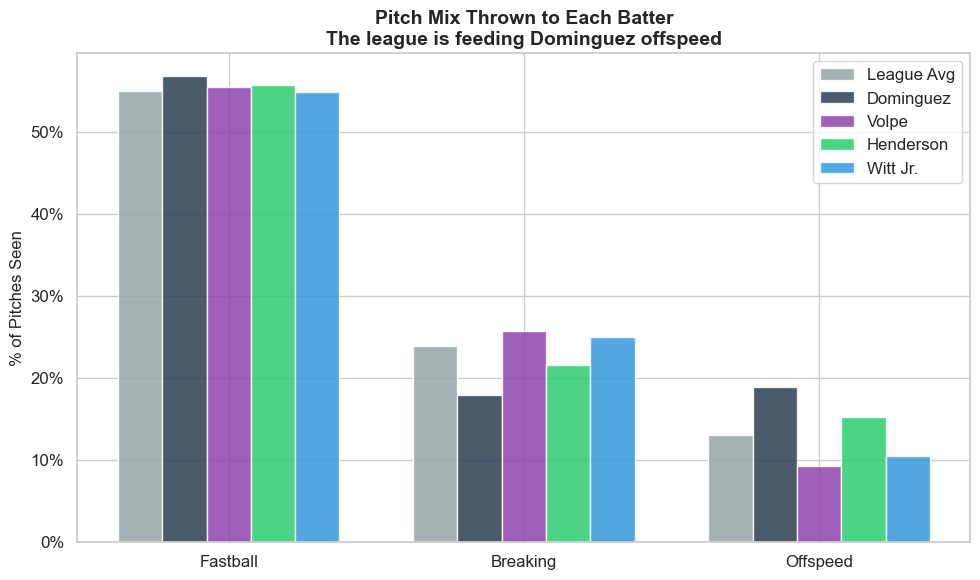

In [4]:
all_pitches = pd.concat([pitches_2023, pitches_2024])

fig, ax = plt.subplots(figsize=(10, 6))

players = [
    ("League Avg", None, "#95a5a6"),
    ("Dominguez", 691176, "#2c3e50"),
    ("Volpe", 683011, "#8e44ad"),
    ("Henderson", 683002, "#2ecc71"),
    ("Witt Jr.", 677951, "#3498db"),
]

x = np.arange(3)
width = 0.15

for i, (name, pid, color) in enumerate(players):
    if pid is None:
        p = all_pitches
    else:
        p = pd.concat([pitches_2023[pitches_2023["batter"] == pid],
                       pitches_2024[pitches_2024["batter"] == pid]])
    vals = [p["pitch_type"].isin(fb_codes).mean(),
            p["pitch_type"].isin(brk_codes).mean(),
            p["pitch_type"].isin(off_codes).mean()]
    ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(["Fastball", "Breaking", "Offspeed"])
ax.set_ylabel("% of Pitches Seen", fontsize=12)
ax.set_title("Pitch Mix Thrown to Each Batter\nThe league is feeding Dominguez offspeed", fontsize=14, fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.savefig("../outputs/figures/pitch_mix_exploitation.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. A Statcast-Based Prospect Readiness Framework

Traditional promotion criteria are backwards. Teams promote on slash lines (.280/.350/.450 in AAA) which are inflated by weak competition. Here's what the data says the gates should be:

In [5]:
# Define readiness gates based on star benchmarks
from fire_fishman.features.pitch_level import compute_pitch_features_for_cohort
from fire_fishman.data.prospects import get_prospect_df

pitches = pd.concat([pitches_2023, pitches_2024], ignore_index=True)
prospects = get_prospect_df()
pitch_features = compute_pitch_features_for_cohort(pitches, prospects["mlbam_id"].tolist())
pitch_features = pitch_features.join(prospects.set_index("mlbam_id")[["name", "outcome"]])

stars = pitch_features[pitch_features["outcome"] == "star"]

gates = {
    "Chase rate on breaking balls": ("chase_rate_breaking", "<", stars["chase_rate_breaking"].quantile(0.75)),
    "Chase rate on offspeed": ("chase_rate_offspeed", "<", stars["chase_rate_offspeed"].quantile(0.75)),
    "Whiff rate vs 96+ mph": ("whiff_rate_elite_96plus", "<", stars["whiff_rate_elite_96plus"].quantile(0.75)),
    "Overall chase rate": ("chase_rate", "<", stars["chase_rate"].quantile(0.75)),
    "Zone contact rate": ("zone_contact_rate", ">", stars["zone_contact_rate"].quantile(0.25)),
}

print("PROPOSED STATCAST READINESS GATES")
print("="*60)
print(f"Based on 75th/25th percentile of successful prospects (n={len(stars)})\n")

for gate_name, (col, direction, threshold) in gates.items():
    print(f"  {gate_name:<35} {direction} {threshold:.1%}")

# Grade Volpe and Dominguez
for name in ["Anthony Volpe", "Jasson Dominguez"]:
    row = pitch_features[pitch_features["name"] == name]
    if len(row) == 0:
        continue
    print(f"\n  {name}:")
    passes = 0
    for gate_name, (col, direction, threshold) in gates.items():
        val = row[col].values[0]
        if np.isnan(val):
            status = "N/A"
        elif direction == "<" and val < threshold:
            status = "✓ PASS"
            passes += 1
        elif direction == ">" and val > threshold:
            status = "✓ PASS"
            passes += 1
        else:
            status = "✗ FAIL"
        print(f"    {gate_name:<35} {val:.1%}  {status}")
    print(f"    Result: {passes}/{len(gates)} gates passed")

PROPOSED STATCAST READINESS GATES
Based on 75th/25th percentile of successful prospects (n=7)

  Chase rate on breaking balls        < 35.5%
  Chase rate on offspeed              < 41.2%
  Whiff rate vs 96+ mph               < 21.5%
  Overall chase rate                  < 32.4%
  Zone contact rate                   > 83.0%

  Anthony Volpe:
    Chase rate on breaking balls        33.0%  ✓ PASS
    Chase rate on offspeed              39.2%  ✓ PASS
    Whiff rate vs 96+ mph               22.3%  ✗ FAIL
    Overall chase rate                  30.6%  ✓ PASS
    Zone contact rate                   85.2%  ✓ PASS
    Result: 4/5 gates passed

  Jasson Dominguez:
    Chase rate on breaking balls        41.3%  ✗ FAIL
    Chase rate on offspeed              39.5%  ✓ PASS
    Whiff rate vs 96+ mph               25.0%  ✗ FAIL
    Overall chase rate                  31.1%  ✓ PASS
    Zone contact rate                   86.3%  ✓ PASS
    Result: 3/5 gates passed


In [6]:
# BACKTEST: How well do these gates separate stars from busts/disappointing?
print("\nGATE BACKTESTING: Would these gates have predicted outcomes?")
print("=" * 70)

for outcome_group, label in [("star", "Stars"), ("solid", "Solid"), 
                               ("disappointing", "Disappointing"), ("bust", "Busts")]:
    group = pitch_features[pitch_features["outcome"] == outcome_group]
    if len(group) == 0:
        continue
    
    print(f"\n  {label} (n={len(group)}):")
    group_pass_counts = []
    for _, row in group.iterrows():
        passes = 0
        total = 0
        for gate_name, (col, direction, threshold) in gates.items():
            val = row[col]
            if np.isnan(val):
                continue
            total += 1
            if direction == "<" and val < threshold:
                passes += 1
            elif direction == ">" and val > threshold:
                passes += 1
        group_pass_counts.append(passes)
        print(f"    {row['name']:<25} {passes}/{total} gates passed")
    
    avg_pass = np.mean(group_pass_counts)
    print(f"    Average: {avg_pass:.1f}/{len(gates)} gates passed")

# Summary separation
print("\n" + "=" * 70)
print("GATE SEPARATION SUMMARY")
print("=" * 70)
for outcome_group in ["star", "solid", "disappointing", "bust"]:
    group = pitch_features[pitch_features["outcome"] == outcome_group]
    if len(group) == 0:
        continue
    pass_rates = []
    for _, row in group.iterrows():
        passes = sum(1 for _, (col, d, t) in gates.items() 
                     if not np.isnan(row[col]) and ((d == "<" and row[col] < t) or (d == ">" and row[col] > t)))
        pass_rates.append(passes / len(gates))
    print(f"  {outcome_group:<15} avg gate pass rate: {np.mean(pass_rates):.0%}")

print("\nIf gates separate stars (>60% pass) from disappointing/busts (<40% pass),")
print("they would have provided an early warning signal for Volpe and Dominguez.")


GATE BACKTESTING: Would these gates have predicted outcomes?

  Stars (n=7):
    Julio Rodriguez           1/5 gates passed
    Bobby Witt Jr.            3/5 gates passed
    Gunnar Henderson          4/5 gates passed
    Corbin Carroll            5/5 gates passed
    Adley Rutschman           5/5 gates passed
    Riley Greene              4/5 gates passed
    Elly De La Cruz           3/5 gates passed
    Average: 3.6/5 gates passed

  Solid (n=8):
    Ben Rice                  5/5 gates passed
    CJ Abrams                 2/5 gates passed
    Jackson Chourio           3/5 gates passed
    Marcelo Mayer             0/0 gates passed
    Nolan Jones               2/5 gates passed
    Josh Jung                 3/5 gates passed
    Ezequiel Tovar            2/5 gates passed
    Matt McLain               5/5 gates passed
    Average: 2.8/5 gates passed

  Disappointing (n=6):
    Anthony Volpe             4/5 gates passed
    Jasson Dominguez          3/5 gates passed
    Spencer Torkels

## 4. In-Season Monitoring Dashboard Concept

The other prevention mechanism: real-time tracking of key metrics with alert thresholds. Volpe's mid-season collapse should have triggered an intervention within 2-3 weeks.

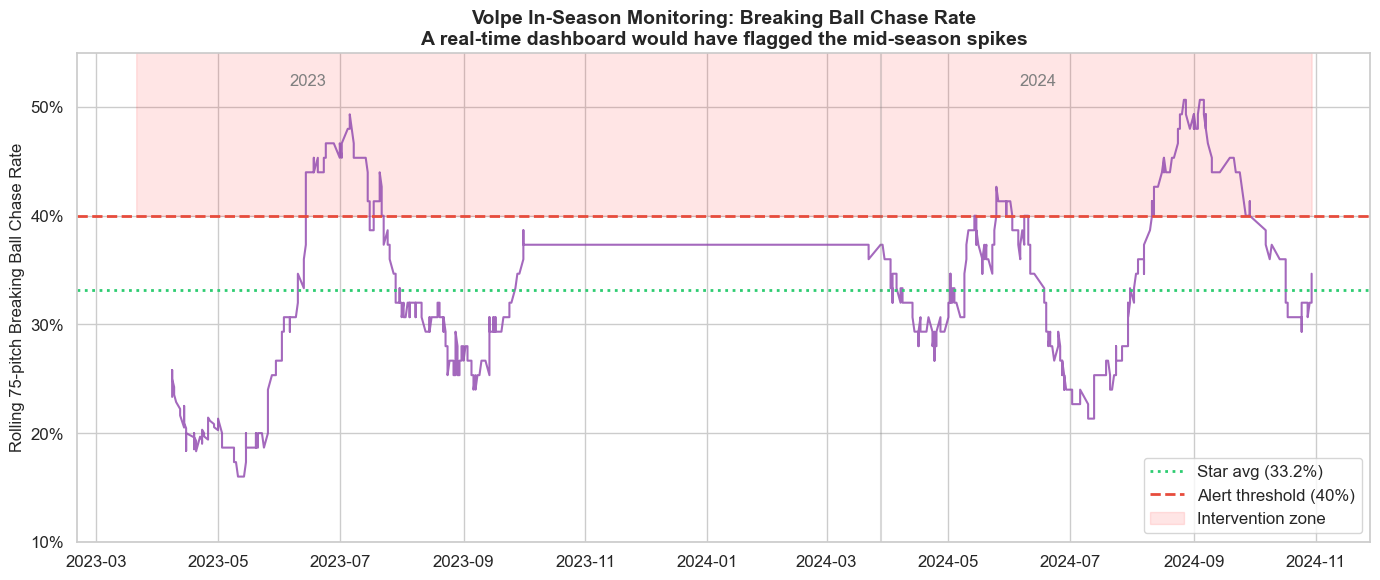

In [7]:
# Rolling 100-pitch breaking ball chase rate for Volpe
volpe_all = pd.concat([
    pitches_2023[pitches_2023["batter"] == 683011],
    pitches_2024[pitches_2024["batter"] == 683011]
]).sort_values("game_date").copy()

volpe_all["is_swing"] = volpe_all["description"].isin([
    "swinging_strike", "swinging_strike_blocked", "foul", "foul_tip",
    "foul_bunt", "hit_into_play", "hit_into_play_score", "hit_into_play_no_out"])
volpe_all["is_zone"] = (volpe_all["plate_x"].abs() <= 0.83) & \
                        (volpe_all["plate_z"] >= volpe_all["sz_bot"]) & \
                        (volpe_all["plate_z"] <= volpe_all["sz_top"])

# Filter to breaking balls outside zone
brk_oz = volpe_all[(volpe_all["pitch_type"].isin(brk_codes)) & (~volpe_all["is_zone"])].copy()
brk_oz["rolling_chase"] = brk_oz["is_swing"].rolling(75, min_periods=30).mean()
brk_oz["game_date"] = pd.to_datetime(brk_oz["game_date"])

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(brk_oz["game_date"], brk_oz["rolling_chase"], color="#8e44ad", linewidth=1.5, alpha=0.8)
ax.axhline(0.332, color="#2ecc71", linestyle=":", linewidth=2, label="Star avg (33.2%)")
ax.axhline(0.40, color="#e74c3c", linestyle="--", linewidth=2, label="Alert threshold (40%)")
ax.fill_between(brk_oz["game_date"], 0.40, 0.55, alpha=0.1, color="red", label="Intervention zone")

# Mark season boundaries
ax.axvline(pd.Timestamp("2024-03-28"), color="gray", linestyle="-", alpha=0.3)
ax.text(pd.Timestamp("2023-06-15"), 0.52, "2023", fontsize=12, ha="center", color="gray")
ax.text(pd.Timestamp("2024-06-15"), 0.52, "2024", fontsize=12, ha="center", color="gray")

ax.set_ylabel("Rolling 75-pitch Breaking Ball Chase Rate", fontsize=12)
ax.set_title("Volpe In-Season Monitoring: Breaking Ball Chase Rate\nA real-time dashboard would have flagged the mid-season spikes", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_ylim(0.1, 0.55)

plt.tight_layout()
plt.savefig("../outputs/figures/volpe_monitoring.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Recommendations: A Better Development Pipeline

### Pre-Promotion
1. **Statcast readiness gates** — Don't promote on slash lines. Gate on: breaking ball chase rate < 35%, offspeed chase rate < 40%, whiff rate vs 96+ < 22%, zone contact > 83%.
2. **Simulated MLB pitch mixes** — In AAA, instruct pitching coaches to throw prospects the pitch mix they'll see in the majors (more offspeed for Dominguez, more elite-velo fastballs for Volpe).
3. **Stress-test weaknesses** — If a prospect has an identifiable hole, *exploit it deliberately* in development. Make them see 96+ in BP. Make them face elite sliders in simulated ABs.

### Post-Promotion
4. **Real-time monitoring with alert thresholds** — Track rolling 75-pitch windows on key metrics. When breaking ball chase rate crosses 40%, trigger a coaching intervention within 1 week.
5. **Approach plan adjustments** — When Volpe's breaking ball chase rate spikes in June, the immediate prescription is: take more pitches, let the pitcher come to you, don't expand.
6. **Development stints** — If metrics don't correct within 3 weeks of intervention, consider a brief AAA reset. The stigma of a demotion is less costly than a lost season.

### The Core Insight
Volpe's plate discipline was real — in the minors. But minor league discipline against minor league breaking balls doesn't guarantee major league discipline against major league breaking balls. The skill is the same; the difficulty is not. The Yankees' development pipeline needs to bridge that gap *before* the call-up, not after.